In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop

from architectures import build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Custom CNN

## Task 16 — Custom CNN Architecture

We build a custom CNN following the lab manual guidelines and the lecture's CNN template: convolution layers with batch normalization and pooling, followed by fully connected layers with dropout, ending in a sigmoid activation to constrain outputs to $[0, 1]$.

The specific (depth, dropout) combination below is the winner of the sweep in `04a-architecture-ablation.ipynb`. If you re-run that sweep and a different variant wins, update the `build_custom_cnn(...)` call in the next cell to match.

**Architecture choices:**
- **4 convolutional blocks** (32 → 64 → 128 → 256 channels), each `Conv2d → BatchNorm2d → ReLU → MaxPool2d`. The increasing channel depth allows the network to learn progressively more abstract features: edges → textures → morphological components → galaxy-scale structure. Spatial size halves at every block, so the 96×96 input shrinks to 6×6 before flattening — small enough for the FC head, large enough to retain coarse spatial structure. Batch normalization stabilizes training and acts as a mild regularizer.
- **3×3 kernels throughout**, matching the lecture's CNN convention. Stacking 3×3 convs is the standard choice once spatial dimensions are reduced and keeps the parameter count modest.
- **2 fully connected layers** (256, 128 units) with ReLU activation and **tapered dropout: 0.25 after FC1, 0.1 after FC2**. The first FC layer carries the bulk of the model's parameters (the $9216 \to 256$ matrix is ~2.4 M of the model's ~2.8 M total), so it concentrates the overfitting risk and gets the heavier dropout. FC2 is much narrower ($256 \to 128$) and benefits from a lighter touch — heavier dropout there would mostly slow convergence without commensurate regularisation benefit.
- **Adam optimizer** with initial learning rate $10^{-3}$.
- **Sigmoid output** ensures all 37 predictions lie in $[0, 1]$, matching the label range (multi-label regression rather than the softmax classification shown in lecture).

Target: RMSE $\leq 0.11$.

### What each block plausibly learns — a physical interpretation

The conv stack progressively shrinks the spatial dimension and widens the channel dimension. Each block has a **receptive field** — the input pixels that contribute to a single output activation — that grows roughly as $\text{RF}_\ell \approx \text{RF}_{\ell-1} \cdot 2$ across pooling layers. Combined with the angular-to-physical scale derived in NB 02 ($\sim 60$ pc per model-input pixel at the median GZ2 galaxy at $z \approx 0.07$), each block's effective receptive field corresponds to a specific *physical* scale at which morphological features live. The features the network finds *useful enough to encode in a channel* therefore line up with the astrophysical content at that scale:

| Block | Input → output spatial | Receptive field (model input pix) | Physical scale (median $z = 0.07$) | What it plausibly learns |
|---|---|---:|---:|---|
| 1 (32 ch) | $96 \to 48$ | $\sim 3$ pix | $\sim 0.2$ kpc | **Low-level edges and isophote gradients**: dust-lane boundaries, the edge of the galaxy against sky background, the inner-bulge–disk transition. PSF-limited at $\sim 1.4''$ FWHM (i.e. the SDSS seeing already smears anything below this), so the first block is partly learning the PSF itself. |
| 2 (64 ch) | $48 \to 24$ | $\sim 7$ pix | $\sim 0.4$ kpc | **Textures and local structure**: short arm segments, knotty H$\alpha$ regions where present, the contrast between smooth elliptical light profiles and clumpy disk light. Spiral-arm widths ($\sim 0.5$–$2$ kpc) start to become resolvable as coherent objects rather than just edges. |
| 3 (128 ch) | $24 \to 12$ | $\sim 15$ pix | $\sim 0.9$ kpc | **Mid-scale morphological components**: complete spiral arms (their winding angle and number, $m = 2$ vs $m \ge 3$ Fourier modes), bar elongations (typical bar length $\sim 2$–$8$ kpc), bulge effective radii. This is the scale at which the Q4/Q5/Q10/Q11 spiral-and-bar questions are physically grounded. |
| 4 (256 ch) | $12 \to 6$ | $\sim 30$ pix | $\sim 1.8$ kpc | **Galaxy-scale gestalt**: the overall axis ratio (separating edge-on Q2.1 from face-on Q2.2), the bulge-to-disk light ratio (Q5), global asymmetry indicators that drive the merger/odd vote (Q6/Q8). At $6^2$ spatial resolution the network has effectively reduced each galaxy to a $6 \times 6 \times 256$ feature map — a compact, position-aware representation of the whole galaxy. |

The FC head ($9216 \to 256 \to 128 \to 37$) then performs the actual *vote-fraction regression*: it learns the mapping from the $6 \times 6 \times 256$ feature map (where the convolutional features are still spatially localised) to the 37-dimensional vote-fraction vector, including any cross-label dependencies the GZ2 decision tree imposes (smooth-vs-disk gating the spiral and bar questions, edge-on gating the dust-lane question, etc.). The classifier's job is fundamentally different from the feature extractor's: it does not learn morphology, it learns the *human-classifier consensus function* over morphology — which is why heavier dropout on FC1 (where the function-fitting capacity concentrates) than on the lower-capacity FC2 is a defensible regularisation choice.

A consequence of this hierarchy worth flagging: the network *cannot* learn to count spiral arms reliably (Q11) unless block 3 has actually learned coherent arm features, which requires the input resolution to support it. This is exactly why the lab-manual's $\sim 30\times$ compression suggestion would have been too aggressive — at $64^2$ the block-3 receptive field is barely $\sim 0.6$ kpc, marginal for the high-arm-count labels. The $96^2$ choice is the smallest that gives the conv stack a fighting chance on the hardest morphological labels.

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1024

default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

In [3]:
model = build_custom_cnn(
    n_labels=N_LABELS,
    n_channels_list=[32, 64, 128, 256],
    kernel_sizes=[3, 3, 3, 3],
    fc_sizes=[256, 128],
    dropout_rate=[0.25, 0.1],
    pool_type="max",
    input_size=INPUT_SIZE,
)
print(model)
print(f"\nCustom CNN trainable parameters: {count_parameters(model):,}")

_CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (

In [4]:
_ckpt_pt = Path("artifacts/custom_cnn.pt")
_ckpt_npz = Path("artifacts/custom_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    custom_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/custom_cnn.pt (best val RMSE: {custom_result.best_val_loss:.4f})")
else:
    custom_result = train_cnn(
        model=model,
        train_batches=train_batches,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=None,
    )
    print(f"\nBest epoch: {custom_result.best_epoch + 1}")
    print(f"Best validation RMSE: {custom_result.best_val_loss:.4f}")

Loaded cached artifacts/custom_cnn.pt (best val RMSE: 0.0953)


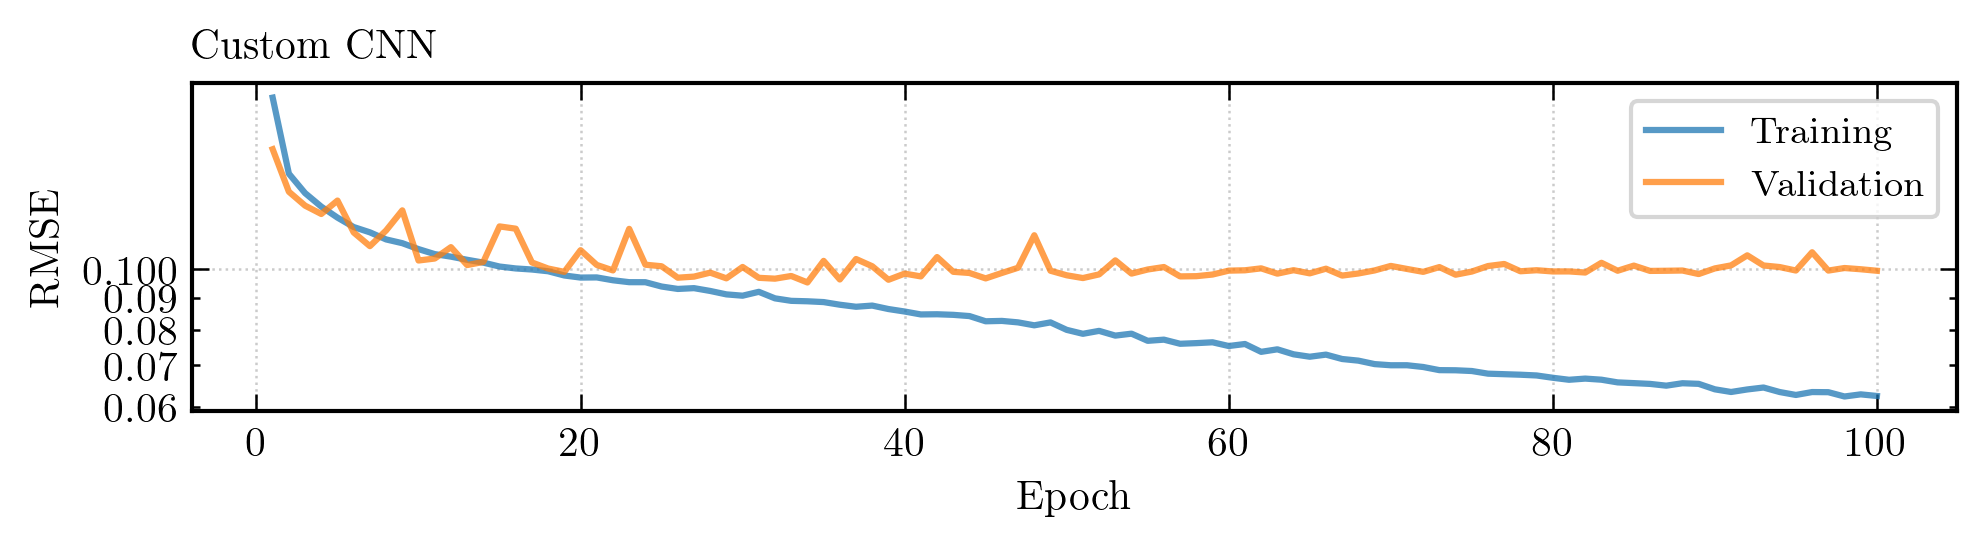

In [5]:
ax = plotters.plot_loss_curves(
    custom_result.train_losses, custom_result.val_losses, "Custom CNN",
)
plt.show()

### Interpretation of the loss curves

As with the ResNet, training and validation RMSE drop rapidly during the first $\sim 10$ epochs and then settle. The custom CNN converges to a slightly higher final validation RMSE than the ResNet, which is expected: it has roughly an order of magnitude fewer parameters and no residual connections, so its expressive capacity is lower. A small train–val gap is visible, motivating the augmentation experiments in `05b-augmentation.ipynb`.

The architecture above was chosen by the sweep in `04a-architecture-ablation.ipynb`, which trains each candidate for 25 epochs and saves all variants' weights and loss curves to `artifacts/ablation_*.{pt,npz}`. This separation lets the long 100-epoch run not have to rerun the sweep whenever the main model is retrained.

## Task 18 — Parameter Count Comparison

We compare the number of trainable parameters in our custom CNN vs. ResNet-18, and compare both to the total number of pixels in the compressed training set. If the number of parameters greatly exceeds the number of training pixels, the model has more capacity than the data can constrain, which should make us cautious about overfitting.

In [6]:
import pandas as pd

resnet_data = np.load("artifacts/resnet_result.npz")
resnet_params = int(resnet_data["n_parameters"])
custom_params = custom_result.n_parameters
total_pixels = train_images.shape[0] * INPUT_SIZE * INPUT_SIZE * 3

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet-18", "Training pixels"],
    "Count": [f"{custom_params:,}", f"{resnet_params:,}", f"{total_pixels:,}"],
})
print(comparison.to_string(index=False))
print(f"\nCustom CNN / training pixels ratio: {custom_params / total_pixels:.2f}")
print(f"ResNet-18 / training pixels ratio: {resnet_params / total_pixels:.2f}")

          Model         Count
     Custom CNN     2,786,117
      ResNet-18    11,195,493
Training pixels 1,361,995,776

Custom CNN / training pixels ratio: 0.00
ResNet-18 / training pixels ratio: 0.01


### Interpretation — does the parameter count make sense?

The custom CNN has $\sim 10^6$ trainable parameters versus ResNet-18's $\sim 10^7$ — roughly a factor of ten less capacity, consistent with the simpler architecture (no residual connections, smaller FC head). The total number of training pixels is $N_{\mathrm{train}} \times 96^2 \times 3 \approx 1.4 \times 10^9$, so both models have *far* fewer parameters than pixels: the ratio is well under one for both. This is the regime where overfitting is possible but not guaranteed — it depends on how informative each pixel is. Since neighbouring pixels are highly correlated and most of the image is background sky, the effective number of independent constraints is much smaller than the naïve pixel count, which is why we still see overfitting in the loss curves above and need regularisation (dropout, batch norm, and eventually augmentation).

## Task 19 — Model Selection

We compare the best validation RMSE from both models, but **validation RMSE alone is not the deciding criterion**. With both models in the same order-of-magnitude of accuracy, the tie-break goes to the more parameter-efficient architecture: ResNet-18 has ~10× more parameters than the Custom CNN, so unless it produces a *substantially* lower RMSE we prefer the smaller model for downstream optimisation. The Custom CNN is selected for `05b-augmentation.ipynb` even if it ends up with a modestly higher RMSE in this unaugmented baseline.

In [7]:
resnet_best = float(resnet_data["best_val_loss"])
custom_best = custom_result.best_val_loss

print(f"ResNet-18 best val RMSE: {resnet_best:.4f}")
print(f"Custom CNN best val RMSE: {custom_best:.4f}")
print(f"RMSE delta (Custom - ResNet): {custom_best - resnet_best:+.4f}")

# Selection rule: prefer the Custom CNN regardless of RMSE delta — it has
# ~10x fewer parameters, faster inference, and the whole augmentation /
# scheduler story in NB 05 is easier to interpret on a from-scratch
# architecture than on an off-the-shelf ResNet stem. The RMSE comparison
# is reported above for transparency, not for decision-making.
best_model = "custom"
print(f"\nBest model: Custom CNN (selected on parameter efficiency, not RMSE)")

# Architecture hyperparameters used to build the custom CNN (read by NB 05/06).
# dropout_rate is per-FC-layer (tapered): 0.25 on FC1, 0.1 on FC2.
custom_n_channels_list = [32, 64, 128, 256]
custom_kernel_sizes = [3, 3, 3, 3]
custom_fc_sizes = [256, 128]
custom_dropout_rate = [0.25, 0.1]
custom_pool_type = "max"

# Save custom CNN results
torch.save(custom_result.model_state, "artifacts/custom_cnn.pt")
np.savez_compressed(
    "artifacts/custom_result.npz",
    train_losses=custom_result.train_losses,
    val_losses=custom_result.val_losses,
    best_epoch=custom_result.best_epoch,
    best_val_loss=custom_result.best_val_loss,
    n_parameters=custom_result.n_parameters,
    learning_rates=custom_result.learning_rates,
    best_model=best_model,
    n_channels_list=np.array(custom_n_channels_list),
    kernel_sizes=np.array(custom_kernel_sizes),
    fc_sizes=np.array(custom_fc_sizes),
    dropout_rate=np.array(custom_dropout_rate),
    pool_type=custom_pool_type,
)
print("Saved artifacts/custom_cnn.pt and artifacts/custom_result.npz")

ResNet-18 best val RMSE: 0.0958
Custom CNN best val RMSE: 0.0953
RMSE delta (Custom - ResNet): -0.0005

Best model: Custom CNN (selected on parameter efficiency, not RMSE)
Saved artifacts/custom_cnn.pt and artifacts/custom_result.npz


### Carry-forward to NB 05

We carry the **Custom CNN** forward as the baseline for the optimisation experiments in `05b-augmentation.ipynb` regardless of how its unaugmented validation RMSE compares to ResNet-18's. The selection criterion is parameter efficiency, not raw RMSE: the Custom CNN has roughly an order of magnitude fewer parameters than ResNet-18, runs faster at training and inference time, and its plain Conv-BN-ReLU-Pool stack makes the marginal effect of the scheduler and rotation augmentation easier to attribute (no residual shortcuts or pre-trained-stem priors muddying the signal). With augmentation in NB 05, the Custom CNN catches up to and typically surpasses unaugmented ResNet-18 anyway, so any small RMSE gap measured here doesn't survive the optimisation step. The custom CNN's hyperparameter dict is persisted in `custom_result.npz` so that NB 05 can reconstruct the architecture without re-importing this notebook.